# Recommendation System Using Item-Based Collaborative Filtering


Check GPU and Install Required Libraries

In [1]:
!nvidia-smi
!pip install gradio -q

Tue Jun  2 17:03:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Mount Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Copy Dataset

In [3]:
import os
import shutil

# CHANGE THIS PATH according to your Google Drive folder
drive_folder = "/content/drive/MyDrive/DMWL/recommendation_system"

colab_folder = "/content/recommendation_system"
os.makedirs(colab_folder, exist_ok=True)

shutil.copy(os.path.join(drive_folder, "movies.csv"), os.path.join(colab_folder, "movies.csv"))
shutil.copy(os.path.join(drive_folder, "ratings.csv"), os.path.join(colab_folder, "ratings.csv"))

print("Dataset copied to Colab storage successfully.")

Dataset copied to Colab storage successfully.


Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

import gradio as gr

Load Dataset

In [5]:
movies = pd.read_csv("/content/recommendation_system/movies.csv")
ratings = pd.read_csv("/content/recommendation_system/ratings.csv")

print("Movies dataset:")
display(movies.head())

print("Ratings dataset:")
display(ratings.head())


Movies dataset:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Ratings dataset:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Dataset Description and Basic Exploration

In [6]:
print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

print("\nMovies columns:")
print(movies.columns)

print("\nRatings columns:")
print(ratings.columns)

print("\nMissing values in movies:")
print(movies.isnull().sum())

print("\nMissing values in ratings:")
print(ratings.isnull().sum())

print("\nNumber of unique users:", ratings["userId"].nunique())
print("Number of unique movies rated:", ratings["movieId"].nunique())
print("Rating range:", ratings["rating"].min(), "to", ratings["rating"].max())

print("\nRatings summary:")
display(ratings["rating"].describe())

Movies shape: (9742, 3)
Ratings shape: (100836, 4)

Movies columns:
Index(['movieId', 'title', 'genres'], dtype='object')

Ratings columns:
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Number of unique users: 610
Number of unique movies rated: 9724
Rating range: 0.5 to 5.0

Ratings summary:


,rating
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


Merge Movies and Ratings

In [7]:
data = pd.merge(ratings, movies, on="movieId", how="left")

print("Merged dataset:")
display(data.head())


Merged dataset:


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Build User-Item Interaction Matrix (Rows = users; Columns = movies; Values = ratings)

In [9]:
user_item_matrix = data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

print("User-item matrix:")
display(user_item_matrix.head())

print("Matrix shape:", user_item_matrix.shape)

User-item matrix:


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Matrix shape: (610, 9719)


Handle Missing Values


In [10]:
# Missing ratings are filled with 0 for similarity calculation.
# 0 means the user has not rated that movie.

user_item_filled = user_item_matrix.fillna(0)

print("Missing values handled.")
display(user_item_filled.head())

Missing values handled.


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Compute Item-Based Cosine Similarity

In [12]:
# Item-based collaborative filtering compares movies based on
# how users rated them.

item_similarity = cosine_similarity(user_item_filled.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_filled.columns,
    columns=user_item_filled.columns
)

print("Item similarity matrix created.")
display(item_similarity_df.head())

Item similarity matrix created.


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.141653,0.0,...,0.0,0.342055,0.543305,0.707107,0.0,0.0,0.139431,0.327327,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,1.000000,0.707107,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Round Midnight (1986),0.0,0.707107,1.000000,0.000000,0.000000,0.0,0.176777,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Salem's Lot (2004),0.0,0.000000,0.000000,1.000000,0.857493,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Til There Was You (1997),0.0,0.000000,0.000000,0.857493,1.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0


Function for Item-Based Top-N Recommendations

In [13]:
def recommend_item_based(user_id, top_n=10):
    """
    Generate Top-N movie recommendations for a given user
    using Item-Based Collaborative Filtering.
    """

    if user_id not in user_item_filled.index:
        return pd.DataFrame({"Message": [f"User ID {user_id} not found."]})

    user_ratings = user_item_filled.loc[user_id]

    rated_movies = user_ratings[user_ratings > 0]

    if rated_movies.empty:
        return pd.DataFrame({"Message": ["This user has no ratings."]})

    recommendation_scores = pd.Series(0, index=user_item_filled.columns, dtype=float)

    for movie, rating in rated_movies.items():
        similar_movies = item_similarity_df[movie]
        recommendation_scores += similar_movies * rating

    recommendation_scores = recommendation_scores.drop(labels=rated_movies.index, errors="ignore")

    top_recommendations = recommendation_scores.sort_values(ascending=False).head(top_n)

    result = pd.DataFrame({
        "Recommended Movie": top_recommendations.index,
        "Recommendation Score": top_recommendations.values
    })

    return result

Show Recommendations for At Least 5 Users

In [16]:
sample_users = list(user_item_filled.index[:5])

for user in sample_users:
    print(f"\nTop 5 Recommendations for User {user}:")
    display(recommend_item_based(user, top_n=5))


Top 5 Recommendations for User 1:


,Recommended Movie,Recommendation Score
0,Ferris Bueller's Day Off (1986),352.684010
1,Die Hard (1988),330.949884
2,"Breakfast Club, The (1985)",328.180507
3,"Fifth Element, The (1997)",326.437374
4,Aliens (1986),323.117648



Top 5 Recommendations for User 2:


,Recommended Movie,Recommendation Score
0,"Hangover, The (2009)",43.201513
1,Fight Club (1999),41.689555
2,Batman Begins (2005),40.674911
3,"Social Network, The (2010)",40.510569
4,Avatar (2009),39.921421



Top 5 Recommendations for User 3:


,Recommended Movie,Recommendation Score
0,RoboCop (1987),18.457292
1,Superman II (1980),16.695882
2,Planet of the Apes (1968),16.609910
3,Predator (1987),16.492577
4,Alien (1979),16.475083



Top 5 Recommendations for User 4:


,Recommended Movie,Recommendation Score
0,Ferris Bueller's Day Off (1986),221.358226
1,Reservoir Dogs (1992),215.959838
2,Who Framed Roger Rabbit? (1988),215.462621
3,Apocalypse Now (1979),213.922116
4,Raising Arizona (1987),213.424545



Top 5 Recommendations for User 5:


,Recommended Movie,Recommendation Score
0,Jurassic Park (1993),69.270489
1,Forrest Gump (1994),67.147349
2,Mrs. Doubtfire (1993),64.736746
3,Speed (1994),64.693511
4,"Silence of the Lambs, The (1991)",63.563467


Prediction Function for Item-Based CF

In [17]:
# Used for RMSE and MAE evaluation.
def predict_item_based_rating(user_id, movie_title):
    """
    Predict a user's rating for a movie using item-based similarity.
    """

    if user_id not in user_item_filled.index:
        return np.nan

    if movie_title not in item_similarity_df.columns:
        return np.nan

    user_ratings = user_item_filled.loc[user_id]

    rated_movies = user_ratings[user_ratings > 0]

    if rated_movies.empty:
        return np.nan

    similarities = item_similarity_df.loc[movie_title, rated_movies.index]

    numerator = np.dot(similarities, rated_movies.values)
    denominator = np.sum(np.abs(similarities))

    if denominator == 0:
        return np.nan

    predicted_rating = numerator / denominator

    return predicted_rating

Train-Test Split for Evaluation

In [18]:
train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

train_matrix = train_data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
).fillna(0)

train_item_similarity = cosine_similarity(train_matrix.T)

train_item_similarity_df = pd.DataFrame(
    train_item_similarity,
    index=train_matrix.columns,
    columns=train_matrix.columns
)


def predict_item_based_train(user_id, movie_title):
    if user_id not in train_matrix.index:
        return np.nan

    if movie_title not in train_item_similarity_df.columns:
        return np.nan

    user_ratings = train_matrix.loc[user_id]
    rated_movies = user_ratings[user_ratings > 0]

    if rated_movies.empty:
        return np.nan

    similarities = train_item_similarity_df.loc[movie_title, rated_movies.index]

    numerator = np.dot(similarities, rated_movies.values)
    denominator = np.sum(np.abs(similarities))

    if denominator == 0:
        return np.nan

    return numerator / denominator

Evaluate Item-Based CF Using RMSE and MAE

In [19]:
actual_ratings = []
predicted_ratings = []

for _, row in test_data.iterrows():
    user_id = row["userId"]
    movie_title = row["title"]
    actual_rating = row["rating"]

    predicted_rating = predict_item_based_train(user_id, movie_title)

    if not np.isnan(predicted_rating):
        actual_ratings.append(actual_rating)
        predicted_ratings.append(predicted_rating)

rmse_item = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings))
mae_item = mean_absolute_error(actual_ratings, predicted_ratings)

print("Item-Based Collaborative Filtering Evaluation")
print("RMSE:", round(rmse_item, 4))
print("MAE:", round(mae_item, 4))

Item-Based Collaborative Filtering Evaluation
RMSE: 0.9202
MAE: 0.7103


BONUS PART 1: User-Based Collaborative Filtering Comparison

In [20]:
user_similarity = cosine_similarity(train_matrix)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)


def predict_user_based_train(user_id, movie_title):
    """
    Predict rating using User-Based Collaborative Filtering.
    """

    if user_id not in train_matrix.index:
        return np.nan

    if movie_title not in train_matrix.columns:
        return np.nan

    movie_ratings = train_matrix[movie_title]
    users_who_rated = movie_ratings[movie_ratings > 0]

    if users_who_rated.empty:
        return np.nan

    similarities = user_similarity_df.loc[user_id, users_who_rated.index]

    numerator = np.dot(similarities, users_who_rated.values)
    denominator = np.sum(np.abs(similarities))

    if denominator == 0:
        return np.nan

    return numerator / denominator


actual_user = []
predicted_user = []

for _, row in test_data.iterrows():
    user_id = row["userId"]
    movie_title = row["title"]
    actual_rating = row["rating"]

    predicted_rating = predict_user_based_train(user_id, movie_title)

    if not np.isnan(predicted_rating):
        actual_user.append(actual_rating)
        predicted_user.append(predicted_rating)

rmse_user = np.sqrt(mean_squared_error(actual_user, predicted_user))
mae_user = mean_absolute_error(actual_user, predicted_user)

print("\nUser-Based Collaborative Filtering Evaluation")
print("RMSE:", round(rmse_user, 4))
print("MAE:", round(mae_user, 4))


User-Based Collaborative Filtering Evaluation
RMSE: 0.969
MAE: 0.7493


BONUS PART 2: Comparison Table

In [21]:
comparison_df = pd.DataFrame({
    "Technique": [
        "Item-Based Collaborative Filtering",
        "User-Based Collaborative Filtering"
    ],
    "RMSE": [rmse_item, rmse_user],
    "MAE": [mae_item, mae_user]
})

display(comparison_df)

best_model = comparison_df.sort_values("RMSE").iloc[0]["Technique"]

print(f"\nBased on RMSE, the better-performing approach is: {best_model}")

,Technique,RMSE,MAE
0,Item-Based Collaborative Filtering,0.920195,0.710332
1,User-Based Collaborative Filtering,0.969002,0.749306



Based on RMSE, the better-performing approach is: Item-Based Collaborative Filtering


BONUS PART 3: Similarity Heatmap

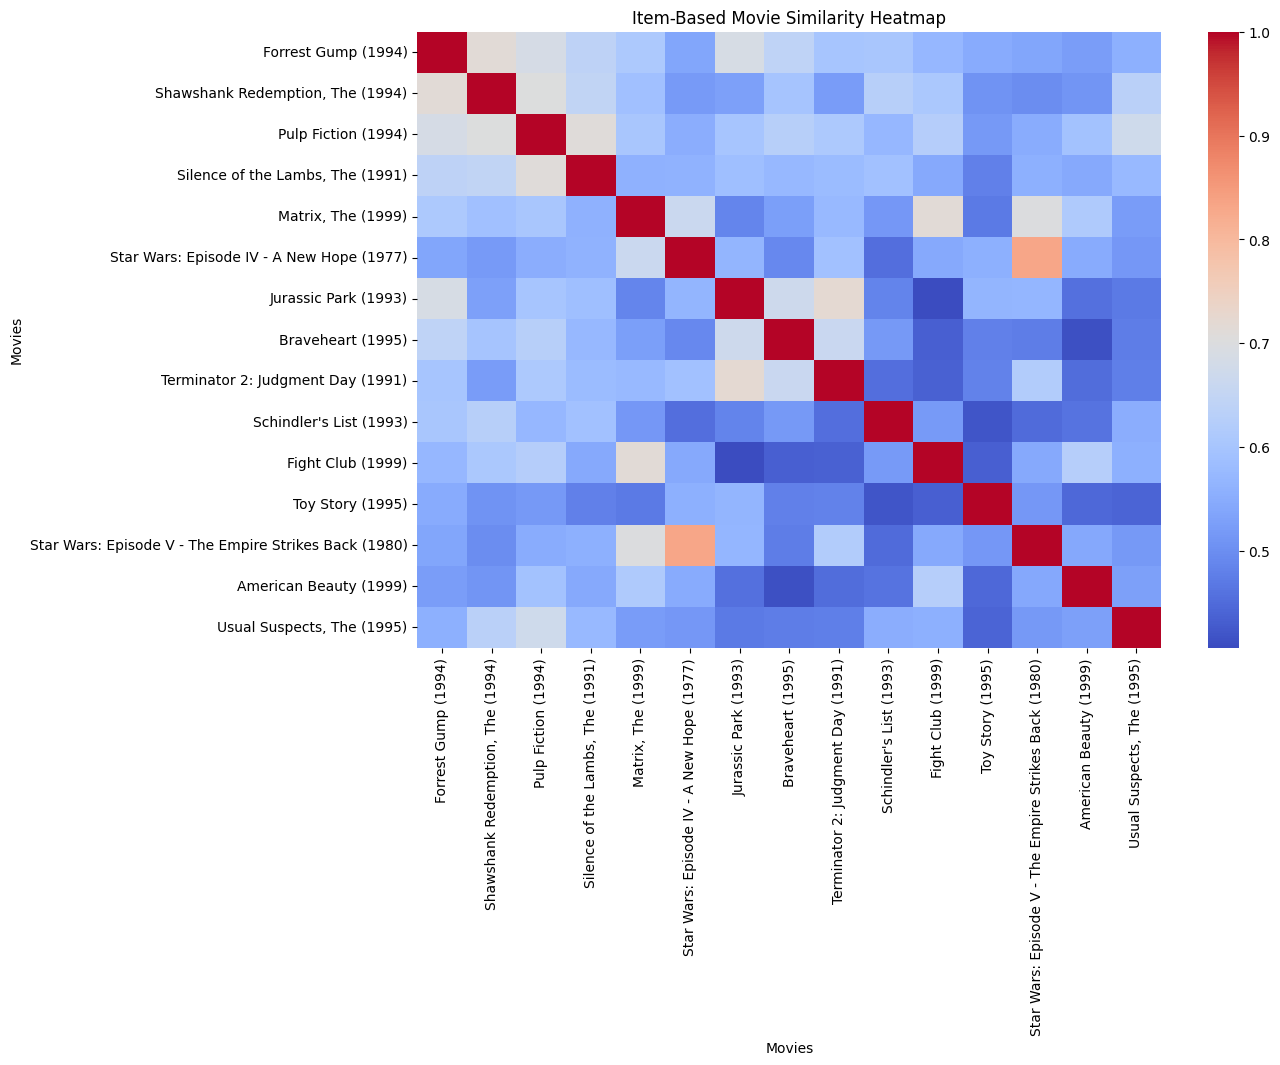

In [22]:
# Use only popular movies to keep the heatmap readable.
movie_rating_counts = data.groupby("title")["rating"].count().sort_values(ascending=False)

top_movies = movie_rating_counts.head(15).index

heatmap_data = item_similarity_df.loc[top_movies, top_movies]

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    annot=False
)

plt.title("Item-Based Movie Similarity Heatmap")
plt.xlabel("Movies")
plt.ylabel("Movies")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


Explaination of the Recommendation Generation

In [23]:
explanation = """
The system uses Item-Based Collaborative Filtering. First, a user-item matrix is created,
where each row represents a user and each column represents a movie. The values are ratings.
Missing values are filled with 0 because they represent movies that users have not rated.

Cosine similarity is then calculated between movies. If two movies receive similar rating
patterns from users, they are considered similar. For a target user, the system checks the
movies already rated by that user. It then finds similar movies and calculates recommendation
scores by weighting movie similarity with the user's previous ratings. Movies already watched
by the user are removed, and the highest-scoring unseen movies are recommended.
"""

print(explanation)


The system uses Item-Based Collaborative Filtering. First, a user-item matrix is created,
where each row represents a user and each column represents a movie. The values are ratings.
Missing values are filled with 0 because they represent movies that users have not rated.

Cosine similarity is then calculated between movies. If two movies receive similar rating
patterns from users, they are considered similar. For a target user, the system checks the
movies already rated by that user. It then finds similar movies and calculates recommendation
scores by weighting movie similarity with the user's previous ratings. Movies already watched
by the user are removed, and the highest-scoring unseen movies are recommended.



BONUS PART 4: Simple Gradio User Interface

In [24]:
# Users can enter a user ID and number of recommendations.
def gradio_recommend(user_id, top_n):
    try:
        user_id = int(user_id)
        top_n = int(top_n)

        recommendations = recommend_item_based(user_id, top_n)

        return recommendations

    except:
        return pd.DataFrame({"Error": ["Please enter a valid user ID and number."]})


user_ids_available = sorted(user_item_filled.index.tolist())

interface = gr.Interface(
    fn=gradio_recommend,
    inputs=[
        gr.Number(label="Enter User ID", value=int(user_ids_available[0])),
        gr.Number(label="Number of Recommendations", value=10)
    ],
    outputs=gr.Dataframe(label="Recommended Movies"),
    title="Movie Recommendation System",
    description="Item-Based Collaborative Filtering Recommendation System using movies.csv and ratings.csv"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6c3f8caaeacc561be8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
